# 03 — Target-definition investigation: are `Transfer` animals really "not adopted"?

**Question.** The current target puts every `outcome_type == 'Transfer'` animal in the negative class (`is_adopted = 0`). Hypothesis: most transfers are young kittens/puppies sent to **Partner** or **Foster** — i.e. successfully placed, not "failed to be adopted". This notebook validates that with data (Dogs & Cats only).

## 0. Setup — filter to Dog & Cat, build helper columns

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
pd.set_option('display.width', 220)
pd.set_option('display.max_columns', 40)
pd.set_option('display.max_rows', 60)

DATA_PATH = '../data/processed/df_full_merged.csv'   # adjust if needed
df = pd.read_csv(DATA_PATH)
print('Filtered to Dog & Cat:', df.shape)

# coarse outcome grouping
def outcome_group(ot):
    if ot in ('Adoption', 'Transfer', 'Return to Owner', 'Euthanasia'):
        return ot
    return 'Other'
GROUP_ORDER = ['Adoption', 'Transfer', 'Return to Owner', 'Euthanasia', 'Other']
df['outcome_group'] = df['outcome_type'].map(outcome_group)

# age buckets (same bins as the EDA / modeling notebooks)
AGE_BINS   = [0, 60, 180, 365, 730, 1825, 3650, 5475, np.inf]
AGE_LABELS = ['<2mo', '2-6mo', '6-12mo', '1-2yr', '2-5yr', '5-10yr', '10-15yr', '15yr+']
df['age_bucket'] = (pd.cut(df['age_at_intake_days'], bins=AGE_BINS, labels=AGE_LABELS, right=False)
                    .astype('object').fillna('Unknown'))
BUCKET_ORDER = AGE_LABELS + ['Unknown']
print('outcome_group counts:', df['outcome_group'].value_counts().to_dict())

Filtered to Dog & Cat: (162765, 21)
outcome_group counts: {'Adoption': 82515, 'Transfer': 46987, 'Return to Owner': 25500, 'Euthanasia': 4742, 'Other': 3021}


## 1. `outcome_subtype` × `outcome_type` crosstab — which outcome does each subtype sit under?

In [2]:
print('=' * 80)
print('ANALYSIS 1 — outcome_subtype x outcome_type')
print('=' * 80)
ct = pd.crosstab(df['outcome_subtype'].fillna('(no subtype)'), df['outcome_type'].fillna('(NaN)'))
# keep only outcome_type columns that actually occur, sorted by total
ct = ct.loc[:, ct.sum(axis=0).sort_values(ascending=False).index]
print(ct.to_string())

print('\nEvery subtype — which outcome_type(s) it hangs under (sorted by n):')
for sub in ct.sum(axis=1).sort_values(ascending=False).index:
    row = ct.loc[sub]
    print(f'  {sub:20s} (n={int(row.sum()):>6,}): ', dict(row[row > 0]))

ANALYSIS 1 — outcome_subtype x outcome_type
outcome_type         Adoption  Transfer  Return to Owner  Euthanasia  Died  Rto-Adopt  Disposal  Missing  (NaN)  Relocate  Stolen  Lost
outcome_subtype                                                                                                                        
(no subtype)            64598         0            25214          31    41       1236       256       16     37         8       5     1
Aggressive                  0         0                0         600     0          0         0        0      0         0       0     0
At Vet                      0         0                1         215   103          0         0        0      0         0       0     0
Barn                        3        13                0           0     0          0         0        0      0         0       0     0
Behavior                    0         0                0         166     0          0         0        0      0         0       0     0
Cour

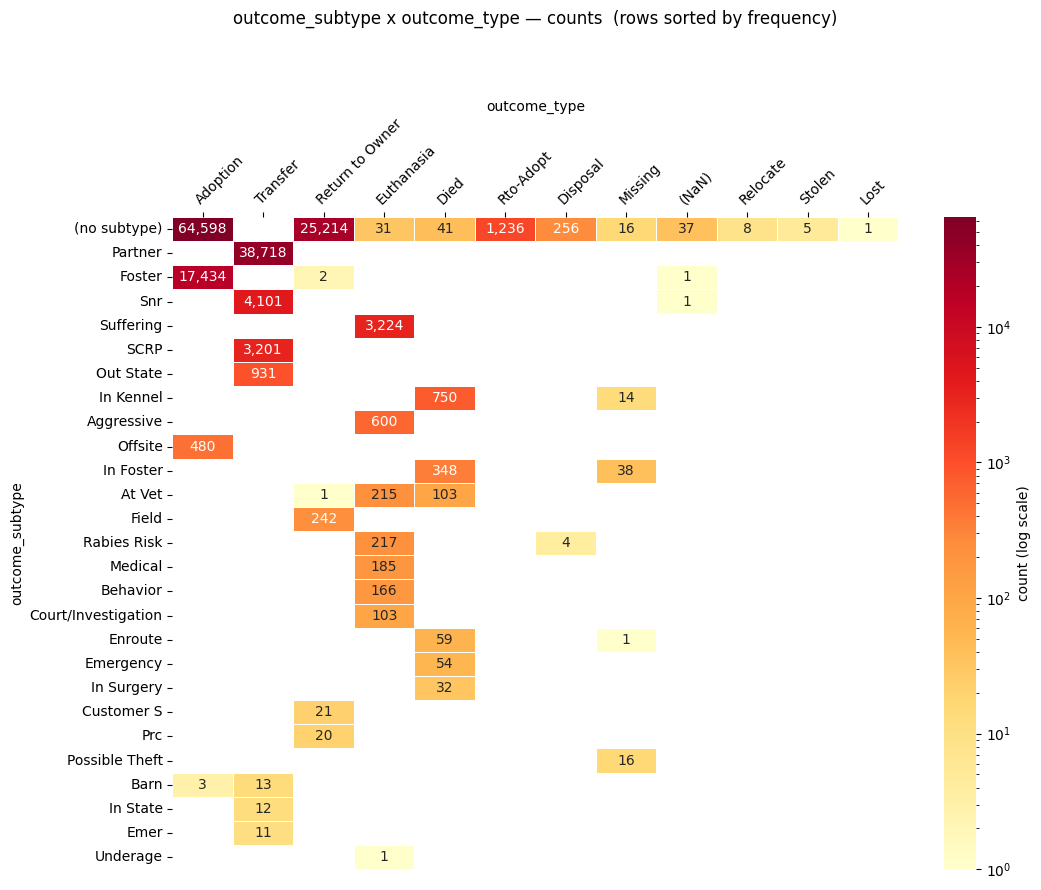

In [3]:
# Heatmap of Analysis 1: raw COUNTS of subtype x outcome_type
# (rows sorted by subtype frequency; blank = 0; log color scale so small cells stay visible)
from matplotlib.colors import LogNorm
ct_sorted = ct.loc[ct.sum(axis=1).sort_values(ascending=False).index]
annot = ct_sorted.map(lambda v: f'{v:,}' if v > 0 else '')
mask = ct_sorted == 0

fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(ct_sorted, annot=annot.values, fmt='', cmap='YlOrRd', mask=mask,
            norm=LogNorm(vmin=1, vmax=ct_sorted.values.max()),
            linewidths=0.4, linecolor='white', cbar_kws={'label': 'count (log scale)'}, ax=ax)
ax.set_title('outcome_subtype x outcome_type — counts  (rows sorted by frequency)', pad=55)
ax.set_xlabel('outcome_type'); ax.set_ylabel('outcome_subtype')
# move the x-axis label and ticks to the TOP
ax.xaxis.set_label_position('top')
ax.tick_params(top=True, bottom=False, labeltop=True, labelbottom=False)
plt.setp(ax.get_xticklabels(), rotation=45, ha='left', rotation_mode='anchor')
plt.tight_layout(); plt.show()

## 2. Age at intake by outcome group, per species (+ where the Transfer group falls)

In [4]:
print('=' * 80)
print('ANALYSIS 2 — age_at_intake_days by outcome group, per species')
print('=' * 80)
for sp in ['Dog', 'Cat']:
    print(f'\n--- {sp} ---')
    g = (df[df.animal_type == sp]
         .groupby('outcome_group')['age_at_intake_days']
         .describe()[['count', 'mean', '25%', '50%', '75%']]
         .reindex(GROUP_ORDER))
    g.columns = ['count', 'mean', 'q25', 'median', 'q75']
    print(g.round(1).to_string())

print('\n--- Transfer group: age-bucket distribution per species ---')
tr = df[df.outcome_group == 'Transfer']
bt = pd.crosstab(tr['animal_type'], tr['age_bucket']).reindex(columns=BUCKET_ORDER, fill_value=0)
print('counts:'); print(bt.to_string())
print('row % (within species):')
print((bt.div(bt.sum(axis=1), axis=0) * 100).round(1).to_string())

ANALYSIS 2 — age_at_intake_days by outcome group, per species

--- Dog ---
                   count    mean    q25  median     q75
outcome_group                                          
Adoption         47129.0   711.6  132.0   365.0   749.0
Transfer         20434.0   822.5  120.0   366.0  1095.0
Return to Owner  22639.0  1489.3  547.0  1085.0  2189.0
Euthanasia        2189.0  1671.0  606.0  1096.0  2556.0
Other             1552.0  1106.0  304.0   730.0  1552.2

--- Cat ---
                   count    mean    q25  median     q75
outcome_group                                          
Adoption         35373.0   403.2   41.0    76.0   365.0
Transfer         26545.0   416.8   22.0    75.0   366.0
Return to Owner   2857.0  1549.4  377.0   923.0  2191.0
Euthanasia        2550.0  1168.1   61.0   366.0  1826.0
Other             1466.0   614.3   29.0    75.0   730.0

--- Transfer group: age-bucket distribution per species ---
counts:
age_bucket    <2mo  2-6mo  6-12mo  1-2yr  2-5yr  5-10yr  10

## 3. Deep-dive: `outcome_subtype == 'Foster'`

In [5]:
print('=' * 80)
print("ANALYSIS 3 — outcome_subtype == 'Foster'")
print('=' * 80)
f = df[df['outcome_subtype'] == 'Foster']
print('n =', len(f))
print('hangs under outcome_type:', df.loc[df.outcome_subtype == 'Foster', 'outcome_type']
      .value_counts(dropna=False).to_dict())
print('is_adopted distribution :', f['is_adopted'].value_counts(dropna=False).to_dict())
print('\nage by species (Foster only):')
fa = (f.groupby('animal_type')['age_at_intake_days']
      .describe()[['count', 'mean', '50%']])
fa.columns = ['count', 'mean', 'median']
print(fa.round(1).to_string())
print('\nage_bucket (Foster only):')
print(pd.crosstab(f['animal_type'], f['age_bucket']).reindex(columns=BUCKET_ORDER, fill_value=0).to_string())

ANALYSIS 3 — outcome_subtype == 'Foster'
n = 17437
hangs under outcome_type: {'Adoption': 17434, 'Return to Owner': 2, nan: 1}
is_adopted distribution : {1: 17434, 0: 3}

age by species (Foster only):
              count   mean  median
animal_type                       
Cat          9996.0  252.4    37.0
Dog          7440.0  916.7   365.0

age_bucket (Foster only):
age_bucket   <2mo  2-6mo  6-12mo  1-2yr  2-5yr  5-10yr  10-15yr  15yr+  Unknown
animal_type                                                                    
Cat          7513    994     166    322    520     318      142     21        0
Dog          2364    597     506    860   1649    1015      418     31        1


## 4. Length of stay by outcome group (+ how many transfers leave within ≤1 day)

In [6]:
print('=' * 80)
print('ANALYSIS 4 — length_of_stay_days by outcome group, per species')
print('=' * 80)
for sp in ['Dog', 'Cat']:
    print(f'\n--- {sp} ---')
    g = (df[df.animal_type == sp]
         .groupby('outcome_group')['length_of_stay_days']
         .describe()[['count', '25%', '50%', '75%']]
         .reindex(GROUP_ORDER))
    g.columns = ['count', 'q25', 'median', 'q75']
    print(g.round(1).to_string())

print('\n--- Transfer group: share leaving within <=1 day (entered & shipped out fast?) ---')
tr = df[df.outcome_group == 'Transfer']
for sp in ['Dog', 'Cat']:
    s = tr[tr.animal_type == sp]['length_of_stay_days']
    print(f'  {sp}: n={len(s):,} | LOS==0 = {(s == 0).mean():.1%} | LOS<=1 = {(s <= 1).mean():.1%} '
          f'| median = {s.median():.0f} d')

print('\n--- LOS<=1 by Transfer subtype ---')
for sub in ['Partner', 'SCRP', 'Snr', 'Out State']:
    s = df.loc[df.outcome_subtype == sub, 'length_of_stay_days']
    if len(s):
        print(f'  {sub:9s}: n={len(s):,} | LOS<=1 = {(s <= 1).mean():.1%} | median = {s.median():.0f} d')

ANALYSIS 4 — length_of_stay_days by outcome group, per species

--- Dog ---
                   count  q25  median   q75
outcome_group                              
Adoption         47138.0  5.0     9.0  32.0
Transfer         20438.0  3.0     5.0  12.0
Return to Owner  22643.0  0.0     1.0   4.0
Euthanasia        2189.0  0.0     4.0  12.0
Other             1554.0  4.0     6.0  14.0

--- Cat ---
                   count  q25  median   q75
outcome_group                              
Adoption         35377.0  7.0    25.0  52.0
Transfer         26549.0  0.0     3.0   6.0
Return to Owner   2857.0  1.0     2.0   6.0
Euthanasia        2553.0  0.0     1.0   4.0
Other             1467.0  3.0     5.0  15.0

--- Transfer group: share leaving within <=1 day (entered & shipped out fast?) ---


  Dog: n=20,438 | LOS==0 = 10.5% | LOS<=1 = 19.1% | median = 5 d
  Cat: n=26,549 | LOS==0 = 28.8% | LOS<=1 = 44.7% | median = 3 d

--- LOS<=1 by Transfer subtype ---
  Partner  : n=38,718 | LOS<=1 = 34.5% | median = 4 d
  SCRP     : n=3,201 | LOS<=1 = 71.2% | median = 1 d
  Snr      : n=4,102 | LOS<=1 = 2.6% | median = 4 d
  Out State: n=931 | LOS<=1 = 1.5% | median = 14 d


## 5. Where do `Suffering`, `Aggressive`, `Rabies Risk`, `Medical` sit?

In [7]:
print('=' * 80)
print('ANALYSIS 5 — outcome_type behind euthanasia-style subtypes')
print('=' * 80)
for sub in ['Suffering', 'Aggressive', 'Rabies Risk', 'Medical']:
    vc = df.loc[df.outcome_subtype == sub, 'outcome_type'].value_counts(dropna=False)
    print(f'  {sub:12s} (n={int(vc.sum()):>5,}): {dict(vc)}')

ANALYSIS 5 — outcome_type behind euthanasia-style subtypes
  Suffering    (n=3,224): {'Euthanasia': np.int64(3224)}
  Aggressive   (n=  600): {'Euthanasia': np.int64(600)}
  Rabies Risk  (n=  221): {'Euthanasia': np.int64(217), 'Disposal': np.int64(4)}
  Medical      (n=  185): {'Euthanasia': np.int64(185)}


## Findings (what the data says)

- **Foster is already positive.** ~17.4k `Foster` rows sit under `Adoption` (`is_adopted = 1`), median age ~46 d (bottle babies). So the negative class does **not** contain fosters — that part of the worry is moot.
- **Transfer cats are young; transfer dogs are not.** Transfer cats: median ~75 d, ~47% under 2 months. Transfer dogs: median ~366 d (≈ adoption dogs) — age-diverse, *not* mostly puppies.
- **Transfer mixes three different things:** `Partner` (rescue placement, ~50% cats, ~52% < 6 mo), and `SCRP` / `Snr` (100% cats, median ~1 yr) which look like **community-cat / TNR returns** — adults who were never adoption candidates yet are currently scored `is_adopted = 0`.
- **Euthanasia subtypes** (`Suffering`, `Aggressive`, `Rabies Risk`, `Medical`) all sit under `Euthanasia` — already excluded as non-modelable.

**Implication for the target (fill in your decision):**
- Treat `Partner`/`Foster` transfers as positive (successful placement)? ____
- Drop `SCRP`/`Snr` (community-cat TNR) from the modelable set, like the other non-adoption-candidate outcomes? ____
- Keep transfer dogs as negative (they really weren't adopted)? ____